# Analyse Exploratoire des Données (EDA) - Profiling des Simulations

Ce notebook présente une analyse détaillée des performances des différents schémas numériques utilisés pour résoudre l'équation de Westervelt.

Les données proviennent de la base de données SQLite générée lors des sessions de validation et de benchmarking.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import sys
import os

# Ajout du chemin racine pour importer les modules du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from core.profiler_db import read_profiler_runs, summarize_by_scheme, performance_vs_mesh, cache_statistics

# Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12


## 1. Chargement des données

On récupère l'ensemble des enregistrements de la base de données SQLite.


In [2]:
df = read_profiler_runs()
print(f"Nombre total d'enregistrements : {len(df)}")
df.head()


Nombre total d'enregistrements : 953


,id,timestamp,function,context,validation_type,scheme,bc,nx,nt,dx,...,A2,c,rho0,beta,mu_v,b,time_total_s,memory_max_mb,loaded_from_cache,cache_path
0,1,2026-05-26T03:50:51.715148,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,51,1,0.02,...,NaN,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.001384,0.005216,0,outputs\cache\solutions\manufactured_explicit_...
1,162,2026-05-26T03:50:51.715148,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,51,1,0.02,...,NaN,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.001384,0.005216,0,outputs\cache\solutions\manufactured_explicit_...
2,383,2026-05-26T03:50:51.715148,run_with_snapshots,run_case_cached,None,explicit,dirichlet,51,1,0.02,...,NaN,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.001384,0.005216,0,outputs\cache\solutions\manufactured_explicit_...
3,2,2026-05-26T03:50:51.740079,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,101,1,0.01,...,NaN,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.000380,0.007575,0,outputs\cache\solutions\manufactured_explicit_...
4,163,2026-05-26T03:50:51.740079,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,101,1,0.01,...,NaN,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.000380,0.007575,0,outputs\cache\solutions\manufactured_explicit_...


## 2. Aperçu Statistique par Schéma

Comparaison globale du temps d'exécution et de la mémoire consommée par les différents schémas.


In [3]:
summary = summarize_by_scheme()
summary


,scheme,n_runs,avg_time_total_s,max_time_total_s,avg_memory_max_mb,max_memory_max_mb
0,explicit,529,0.431093,87.629426,15.188116,1254.158067
1,semi_implicit,424,37.211823,2226.525565,7.013888,314.863251


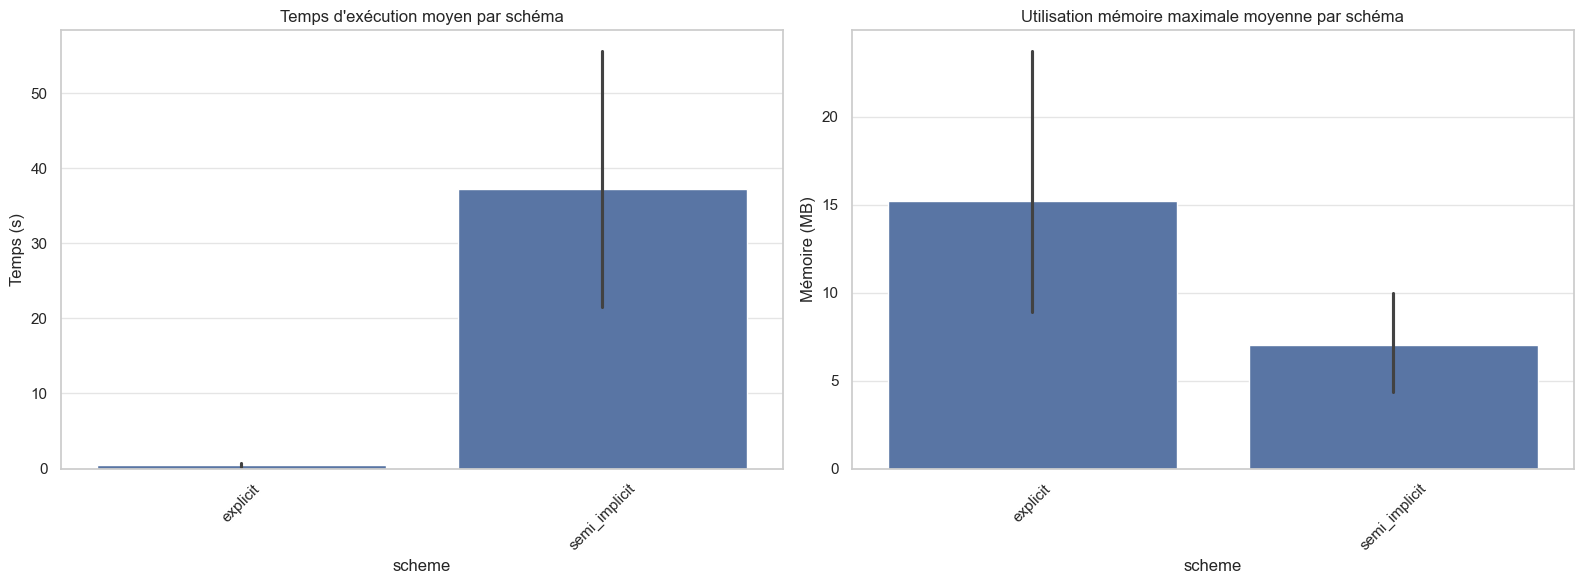

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temps moyen par schéma
sns.barplot(data=df, x='scheme', y='time_total_s', ax=axes[0])
axes[0].set_title('Temps d\'exécution moyen par schéma')
axes[0].set_ylabel('Temps (s)')
axes[0].tick_params(axis='x', rotation=45)

# Mémoire max par schéma
sns.barplot(data=df, x='scheme', y='memory_max_mb', ax=axes[1])
axes[1].set_title('Utilisation mémoire maximale moyenne par schéma')
axes[1].set_ylabel('Mémoire (MB)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Analyse de la Complexité (Scaling)

On observe comment le temps d'exécution et l'utilisation mémoire évoluent avec la taille du maillage (`nx`). On exclut les données provenant du cache pour mesurer le coût réel du calcul.


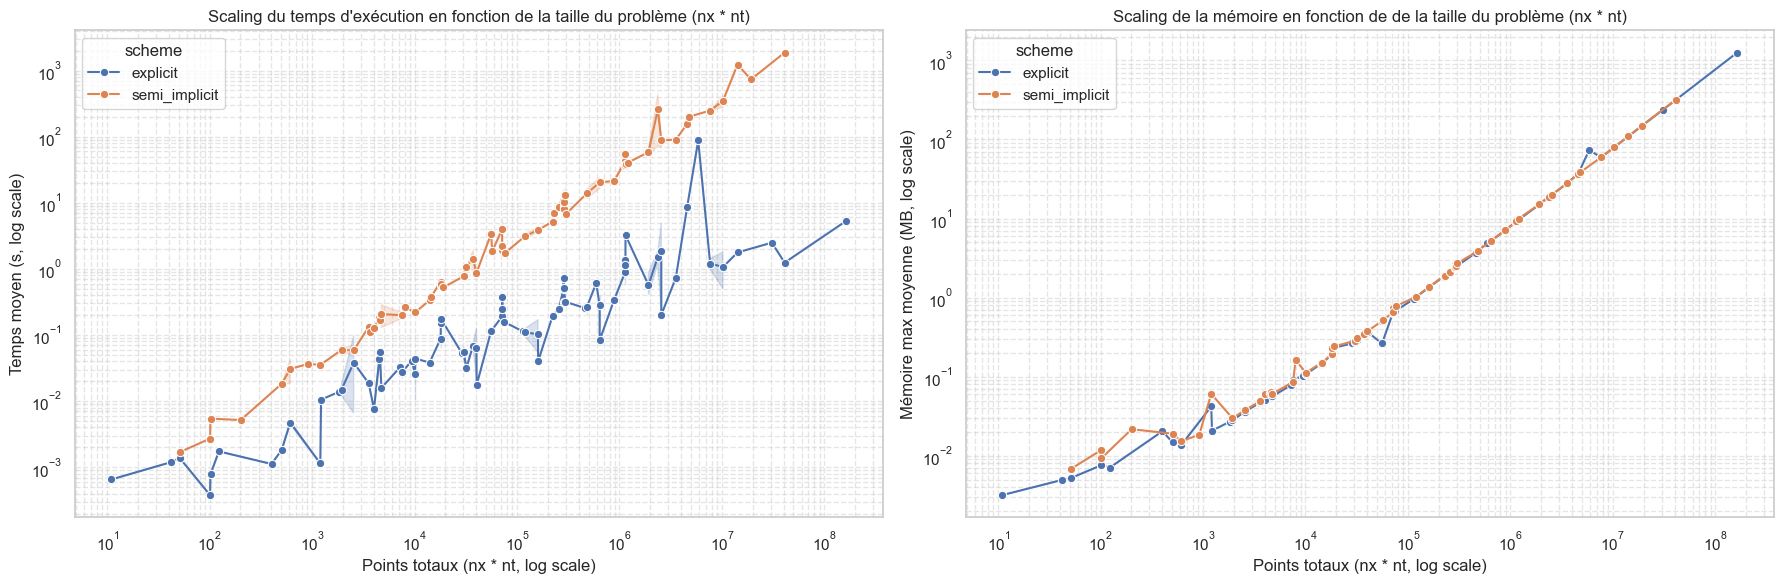

In [5]:
scaling_df = performance_vs_mesh(exclude_cache=True)
scaling_df['total_points'] = scaling_df['nx'] * scaling_df['nt']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scaling Temps vs Taille du problème
sns.lineplot(data=scaling_df, x='total_points', y='avg_time_total_s', hue='scheme', marker='o', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_title('Scaling du temps d\'exécution en fonction de la taille du problème (nx * nt)')
axes[0].set_xlabel('Points totaux (nx * nt, log scale)')
axes[0].set_ylabel('Temps moyen (s, log scale)')
axes[0].grid(True, which="both", ls="--")

# Scaling Mémoire (toujours principalement lié à nx)
sns.lineplot(data=scaling_df, x='total_points', y='avg_memory_max_mb', hue='scheme', marker='o', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Scaling de la mémoire en fonction de de la taille du problème (nx * nt)')
axes[1].set_xlabel('Points totaux (nx * nt, log scale)')
axes[1].set_ylabel('Mémoire max moyenne (MB, log scale)')
axes[1].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()


## 4. Analyse de la Complexité en temps (Scaling vs nt)

Bien que la taille totale $nx \times nt$ soit le facteur principal du temps d'exécution, on peut isoler l'impact de $nt$ pour vérifier le scaling linéaire temporel.

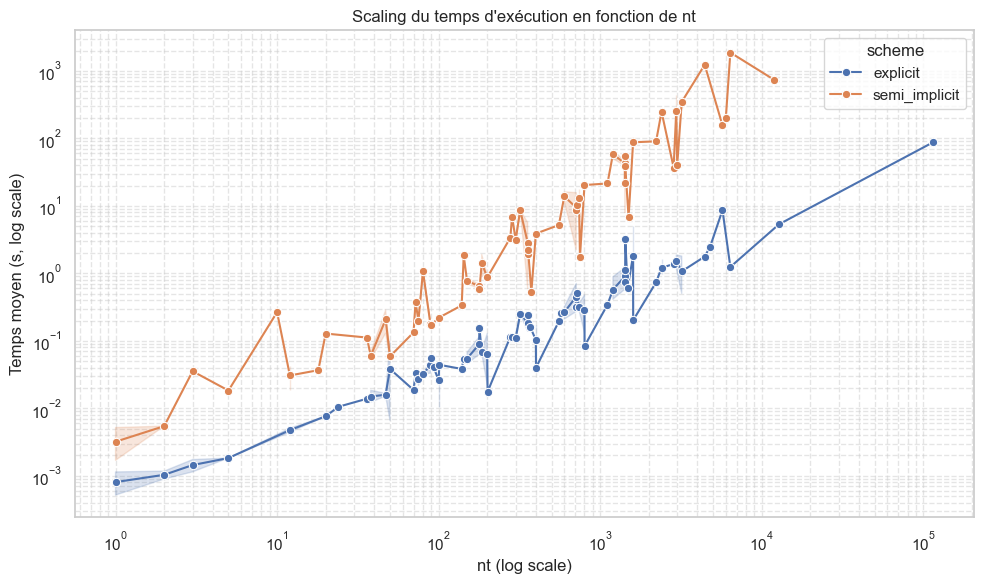

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Scaling Temps vs nt
sns.lineplot(data=scaling_df, x='nt', y='avg_time_total_s', hue='scheme', marker='o', ax=axes)
axes.set_yscale('log')
axes.set_xscale('log')
axes.set_title('Scaling du temps d\'exécution en fonction de nt')
axes.set_xlabel('nt (log scale)')
axes.set_ylabel('Temps moyen (s, log scale)')
axes.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()


## 5. Efficacité du Cache

Comparaison entre les exécutions réelles et les récupérations depuis le cache.


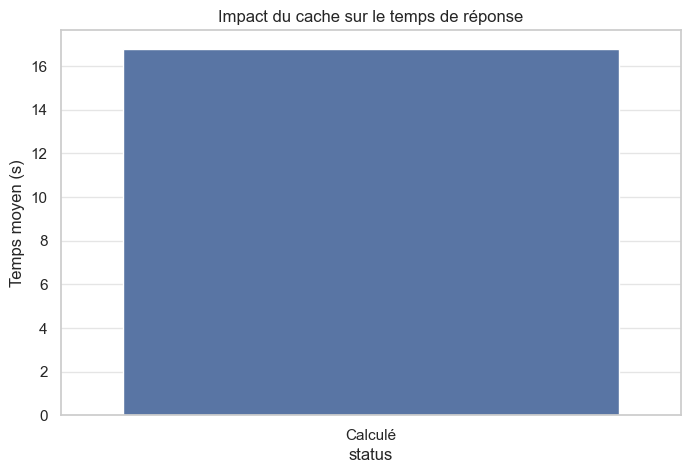

Statistiques de cache :
    status  n_runs  avg_time_total_s  avg_memory_max_mb
0  Calculé     953         16.795237          11.551314


In [7]:
cache_stats = cache_statistics()
if not cache_stats.empty:
    cache_stats['status'] = cache_stats['loaded_from_cache'].map({0: 'Calculé', 1: 'Depuis Cache'})

    plt.figure(figsize=(8, 5))
    sns.barplot(data=cache_stats, x='status', y='avg_time_total_s')
    plt.title('Impact du cache sur le temps de réponse')
    plt.ylabel('Temps moyen (s)')
    plt.show()

    print("Statistiques de cache :")
    print(cache_stats[['status', 'n_runs', 'avg_time_total_s', 'avg_memory_max_mb']])
else:
    print("Aucune donnée de cache disponible.")


## 6. Analyse par type de validation

Les performances varient-elles selon le type de cas test (Nikolic, Gaussian, Analytical) ?


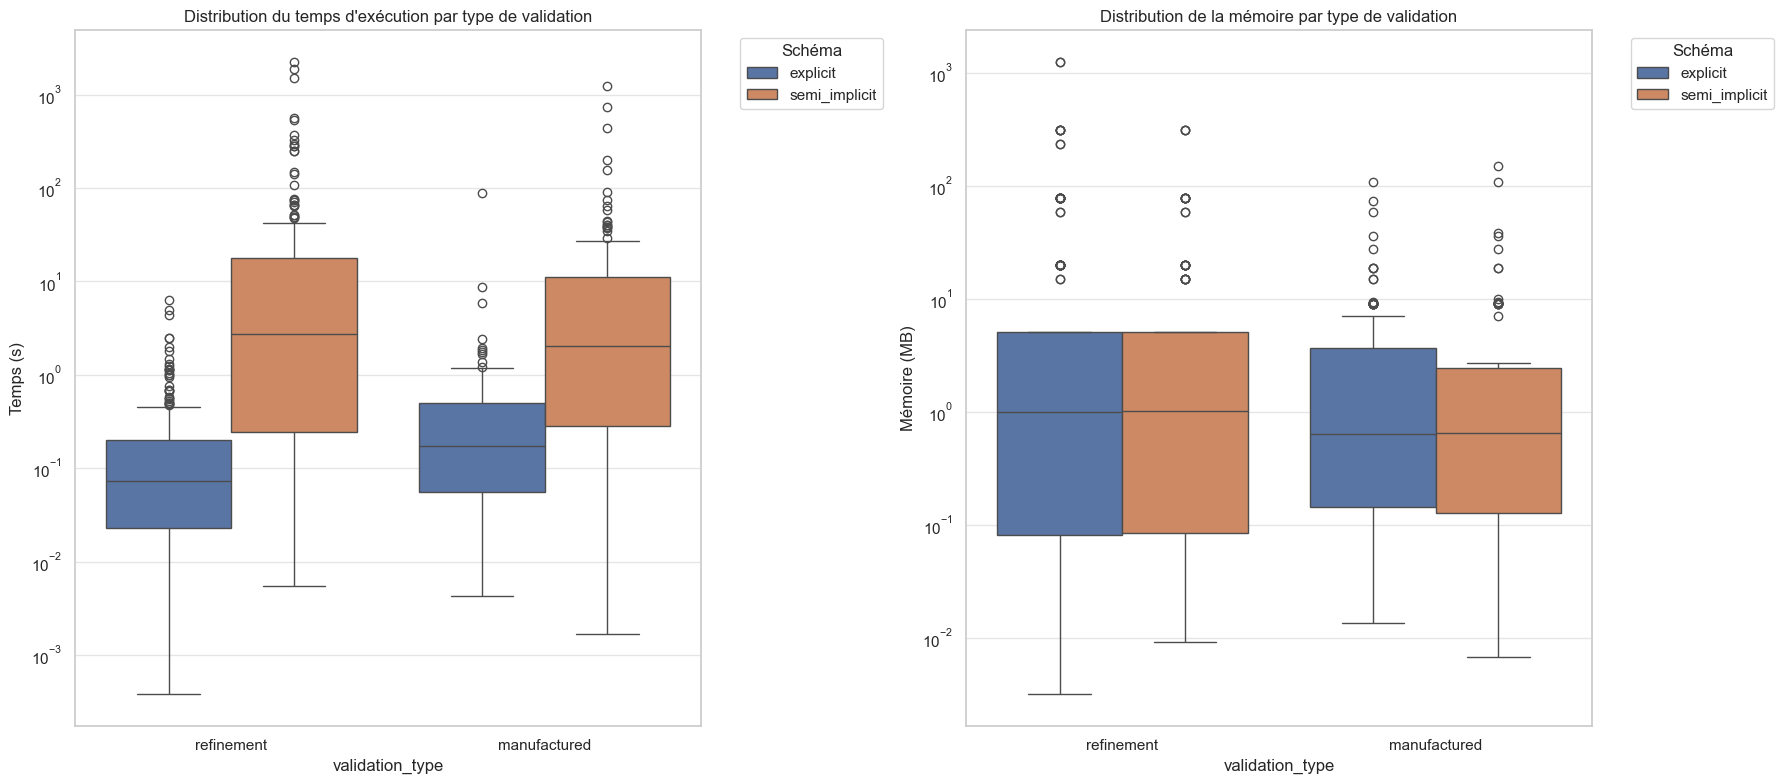

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Boxplot Temps
sns.boxplot(data=df, x='validation_type', y='time_total_s', hue='scheme', ax=axes[0])
axes[0].set_title('Distribution du temps d\'exécution par type de validation')
axes[0].set_ylabel('Temps (s)')
axes[0].set_yscale('log')
axes[0].legend(title='Schéma', bbox_to_anchor=(1.05, 1), loc='upper left')

# Boxplot Mémoire
sns.boxplot(data=df, x='validation_type', y='memory_max_mb', hue='scheme', ax=axes[1])
axes[1].set_title('Distribution de la mémoire par type de validation')
axes[1].set_ylabel('Mémoire (MB)')
axes[1].set_yscale('log')
axes[1].legend(title='Schéma', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 7. Analyse des Corrélations et Facteurs d'Influence

Exploration de l'impact combiné de `nx` et `nt` sur les performances.


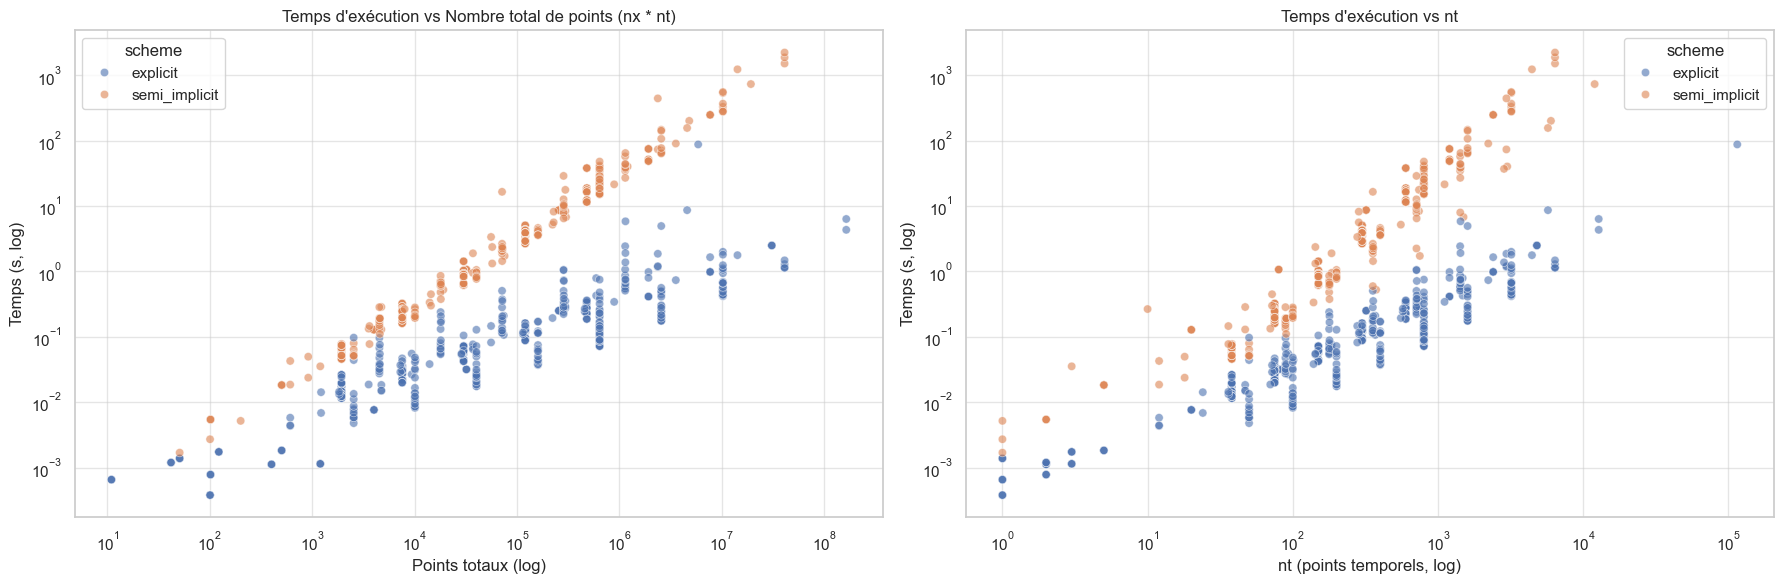

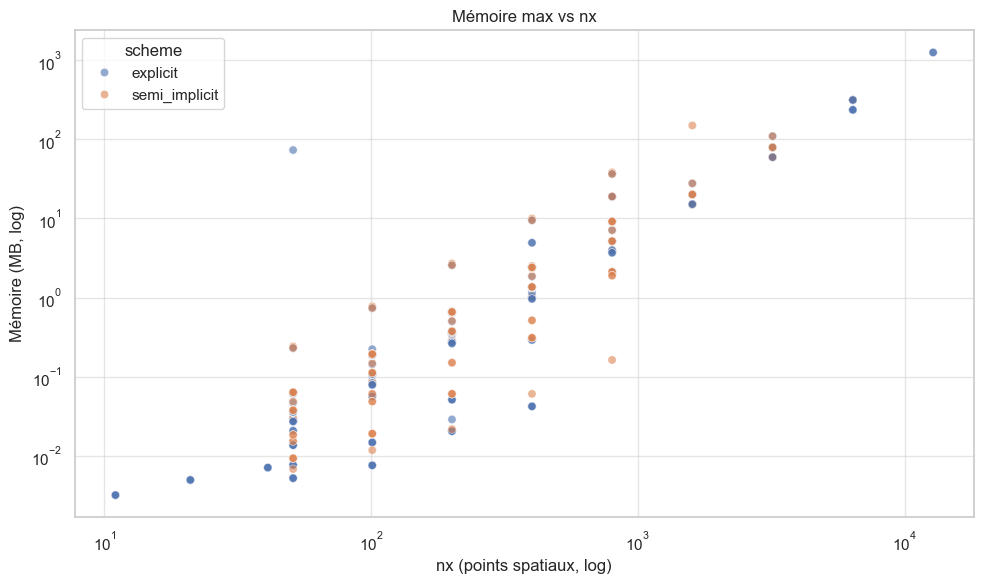

In [9]:
# On ne garde que les simulations réelles (hors cache)
df_real = df[df['loaded_from_cache'] == 0].copy()

# Calcul du nombre total de points spatio-temporels
df_real['total_points'] = df_real['nx'] * df_real['nt']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Relation entre points totaux et temps
sns.scatterplot(data=df_real, x='total_points', y='time_total_s', hue='scheme', alpha=0.6, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Temps d\'exécution vs Nombre total de points (nx * nt)')
axes[0].set_xlabel('Points totaux (log)')
axes[0].set_ylabel('Temps (s, log)')

# Relation entre nt et temps
sns.scatterplot(data=df_real, x='nt', y='time_total_s', hue='scheme', alpha=0.6, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Temps d\'exécution vs nt')
axes[1].set_xlabel('nt (points temporels, log)')
axes[1].set_ylabel('Temps (s, log)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Relation entre nx et mémoire
sns.scatterplot(data=df_real, x='nx', y='memory_max_mb', hue='scheme', alpha=0.6, ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_title('Mémoire max vs nx')
axes.set_xlabel('nx (points spatiaux, log)')
axes.set_ylabel('Mémoire (MB, log)')

plt.tight_layout()
plt.show()


## 8. Analyse Détaillée par Fonction (Profiling Granulaire)

Quelles fonctions consomment le plus de ressources au sein du solveur ?


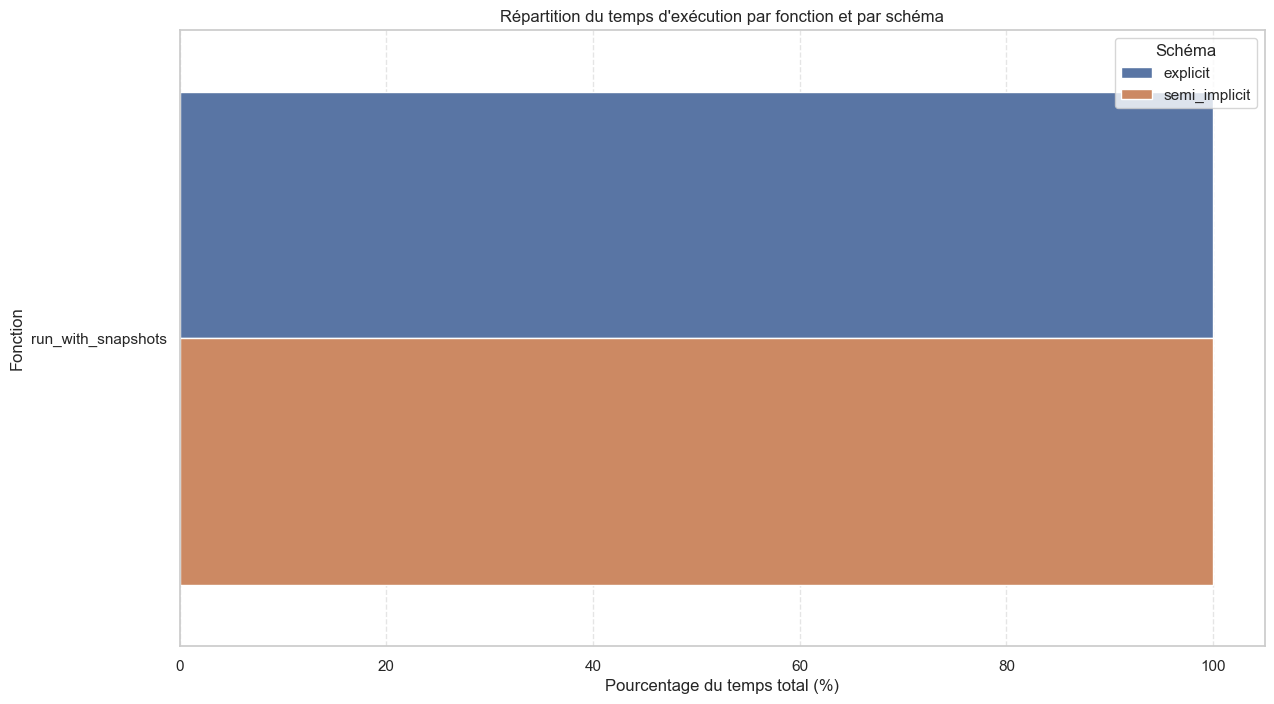

In [10]:
# On agrège le temps passé dans chaque fonction
func_stats = df_real.groupby(['scheme', 'function'])['time_total_s'].sum().reset_index()

# Calcul du pourcentage de temps par schéma
total_time_per_scheme = func_stats.groupby('scheme')['time_total_s'].transform('sum')
func_stats['percentage'] = (func_stats['time_total_s'] / total_time_per_scheme) * 100

plt.figure(figsize=(14, 8))
sns.barplot(data=func_stats, x='percentage', y='function', hue='scheme')
plt.title('Répartition du temps d\'exécution par fonction et par schéma')
plt.xlabel('Pourcentage du temps total (%)')
plt.ylabel('Fonction')
plt.legend(title='Schéma')
plt.grid(True, axis='x', ls='--')
plt.show()


## Conclusion

- **Performances par schéma** : Identifier les schémas offrant le meilleur compromis temps/mémoire.
- **Scaling** : Vérifier que la complexité temporelle est proche de $O(nx \cdot nt)$, confirmant le scaling linéaire par rapport à `nx` et `nt`. La mémoire scale linéairement avec $O(nx)$.
- **Goulots d'étranglement** : Les fonctions comme `_laplacian_all` ou les étapes de résolution spécifiques (`step_explicit`, `step_semi_implicit`) sont-elles les plus coûteuses ?
- **Efficacité du cache** : Confirmer que la mise en cache réduit drastiquement le temps de réponse pour les validations répétées sans augmenter l'empreinte mémoire.
